<a href="https://colab.research.google.com/github/Stecklert1/UST--Deep-Learning-2026/blob/main/Deep%20Learning%20Final%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Reordered Notebook for Smooth Execution

#### 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### 2. Install Required Libraries

In [ ]:
# Install the transformers library if you haven't already
!pip install transformers scikit-learn torch

#### 3. Import Core Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import numpy as np
import torch
import torch.nn.functional as F
import os
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset

#### 4. Load the Dataset

In [ ]:
zip_file_path = '/content/drive/MyDrive/Training_Essay_Data.csv.zip'
extraction_path = '/content/'

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# Assuming the CSV inside the zip has a similar name or is the only CSV
csv_file_name = 'Training_Essay_Data.csv'
csv_file_path = f'{extraction_path}{csv_file_name}'
df = pd.read_csv(csv_file_path)

display(df.head())

,text,generated
0,Car-free cities have become a subject of incre...,1
1,"Car Free Cities Car-free cities, a concept ga...",1
2,A Sustainable Urban Future Car-free cities ...,1
3,Pioneering Sustainable Urban Living In an e...,1
4,The Path to Sustainable Urban Living In an ...,1


#### 5. Visualize Dataset Class Distribution

Class distribution of the dataset:


,count
generated,
0,17508
1,11637


/tmp/ipykernel_532/1688257914.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='generated', data=df, palette='viridis')


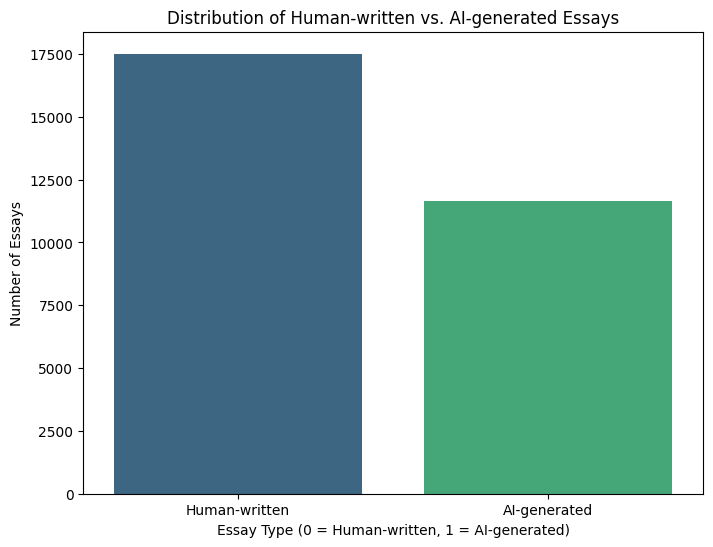

In [ ]:
print("Class distribution of the dataset:")
display(df['generated'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='generated', data=df, palette='viridis')
plt.title('Distribution of Human-written vs. AI-generated Essays')
plt.xlabel('Essay Type (0 = Human-written, 1 = AI-generated)')
plt.ylabel('Number of Essays')
plt.xticks(ticks=[0, 1], labels=['Human-written', 'AI-generated'])
plt.show()

The plot above shows the count of essays for each class (human-written and AI-generated). This visualization helps confirm the class balance in the dataset before training the model.

#### 6. Prepare Data for Model Training

In [ ]:
# Split the dataset into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Load the DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_function(texts):
    # Tokenize the input texts and return PyTorch tensors
    return tokenizer(texts, padding=True, truncation=True, return_tensors='pt')

# Tokenize training and testing texts
train_encodings = tokenize_function(train_df['text'].tolist())
test_encodings = tokenize_function(test_df['text'].tolist())

# Prepare labels as PyTorch tensors
train_labels = torch.tensor(train_df['generated'].tolist())
test_labels = torch.tensor(test_df['generated'].tolist())

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print("Tokenization complete.")

Training set size: 23316
Test set size: 5829
Tokenization complete.


In [ ]:
# Create TensorDatasets
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_labels)
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)

# Create DataLoaders
batch_size = 16 # You can adjust this batch size based on your GPU memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load pre-trained DistilBERT model for sequence classification
# We're specifying num_labels=2 for binary classification
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

print("Model and DataLoaders prepared.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and DataLoaders prepared.


#### 7. Define Training and Evaluation Functions, and Train the Model

In [ ]:
import torch
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from transformers import DistilBertForSequenceClassification # Import needed for re-initialization

# Set device to GPU if available, else CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        optimizer.zero_grad()
        input_ids, attention_mask, labels = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    return total_loss / len(dataloader)

def evaluate_epoch(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []
    total_eval_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            logits = outputs.logits
            loss = outputs.loss
            total_eval_loss += loss.item()
            preds = torch.argmax(logits, dim=1).flatten()

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, predictions, average='binary', zero_division=0)
    return accuracy, precision, recall, f1, total_eval_loss / len(dataloader)

def run_training_experiment(model_instance, train_dl, test_dl, device_arg, lr, wd, num_epochs, es_threshold=3):
    """
    Runs a single training and evaluation experiment with specified hyperparameters.
    Returns the best F1-score, final accuracy, and final validation loss.
    """
    model_instance.to(device_arg)
    optimizer = AdamW(model_instance.parameters(), lr=lr, weight_decay=wd)

    best_f1 = -1.0
    patience_counter = 0
    final_accuracy = 0.0
    final_val_loss = 0.0
    best_epoch_metrics = {}

    print(f"  Training with LR={lr}, WD={wd}, Epochs={num_epochs}")

    # Lists to store metrics for plotting for this specific run
    run_train_losses = []
    run_val_losses = []
    run_test_accuracies = []
    run_test_precisions = []
    run_test_recalls = []
    run_test_f1_scores = []

    for epoch in range(num_epochs):
        train_loss = train_epoch(model_instance, train_dl, optimizer, device_arg)
        accuracy, precision, recall, f1, val_loss = evaluate_epoch(model_instance, test_dl, device_arg)

        # Store metrics for this run
        run_train_losses.append(train_loss)
        run_val_losses.append(val_loss)
        run_test_accuracies.append(accuracy)
        run_test_precisions.append(precision)
        run_test_recalls.append(recall)
        run_test_f1_scores.append(f1)

        # Update final metrics with the last epoch's results
        final_accuracy = accuracy
        final_val_loss = val_loss

        print(f"  Epoch {epoch + 1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Test Accuracy = {accuracy:.4f}, Precision = {precision:.4f}, Recall = {recall:.4f}, F1-score = {f1:.4f}")

        if not np.isnan(f1):
            if f1 > best_f1:
                best_f1 = f1
                patience_counter = 0
                best_epoch_metrics = {
                    'accuracy': accuracy,
                    'precision': precision,
                    'recall': recall,
                    'f1': f1,
                    'val_loss': val_loss,
                    'epoch': epoch + 1
                }
            else:
                patience_counter += 1

            if patience_counter >= es_threshold:
                print(f"  Early stopping triggered after {epoch + 1} epochs.")
                break
        else:
            print(f"  Warning: F1-score was NaN in epoch {epoch + 1}. Skipping early stopping check.")

    if best_epoch_metrics:
        print(f"  Best F1-score achieved in epoch {best_epoch_metrics['epoch']}: {best_f1:.4f}")
        return run_train_losses, run_val_losses, run_test_accuracies, run_test_precisions, run_test_recalls, run_test_f1_scores
    else: # In case of all NaN F1 or no improvement, return the last computed metrics
        return run_train_losses, run_val_losses, run_test_accuracies, run_test_precisions, run_test_recalls, run_test_f1_scores


In [ ]:
# Define hyperparameters for the training run
learning_rate = 5e-5
weight_decay = 0.01
num_train_epochs = 3 # You can adjust the number of epochs
early_stopping_threshold = 2 # Number of epochs to wait for improvement before stopping

print(f"Starting training with: LR={learning_rate}, WD={weight_decay}, Epochs={num_train_epochs}")

# Run the training experiment and capture all returned metrics
train_losses, val_losses, test_accuracies, test_precisions, test_recalls, test_f1_scores = run_training_experiment(
    model_instance=model, # Use the model loaded previously
    train_dl=train_loader, # Use the train_loader created previously
    test_dl=test_loader, # Use the test_loader created previously
    device_arg=device, # Use the device (cuda/cpu) defined previously
    lr=learning_rate,
    wd=weight_decay,
    num_epochs=num_train_epochs,
    es_threshold=early_stopping_threshold
)

print("Training complete. Metrics collected for plotting.")

Starting training with: LR=5e-05, WD=0.01, Epochs=3
  Training with LR=5e-05, WD=0.01, Epochs=3
  Epoch 1/3: Train Loss = 0.0405, Val Loss = 0.0178, Test Accuracy = 0.9949, Precision = 0.9879, Recall = 0.9991, F1-score = 0.9935
  Epoch 2/3: Train Loss = 0.0119, Val Loss = 0.0065, Test Accuracy = 0.9967, Precision = 0.9935, Recall = 0.9983, F1-score = 0.9959
  Epoch 3/3: Train Loss = 0.0078, Val Loss = 0.0141, Test Accuracy = 0.9962, Precision = 0.9996, Recall = 0.9908, F1-score = 0.9952
  Best F1-score achieved in epoch 2: 0.9959
Training complete. Metrics collected for plotting.


#### 8. Plot Training and Evaluation Metrics

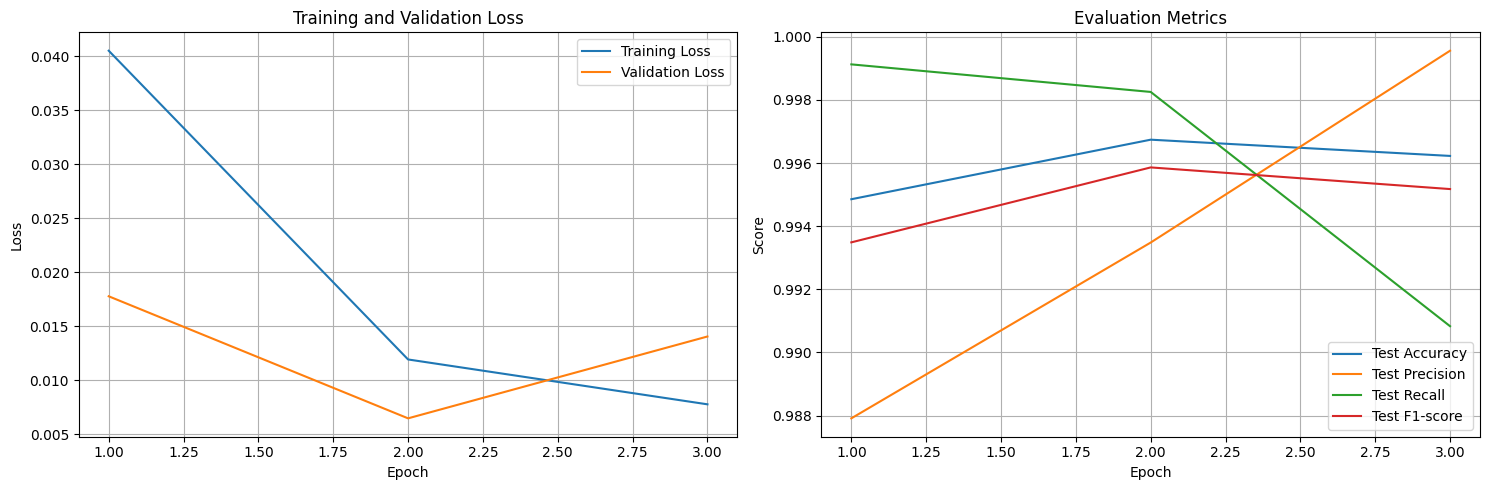

In [ ]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(15, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Evaluation Metrics (Accuracy, Precision, Recall, F1-score)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.plot(epochs_range, test_precisions, label='Test Precision')
plt.plot(epochs_range, test_recalls, label='Test Recall')
plt.plot(epochs_range, test_f1_scores, label='Test F1-score')
plt.title('Evaluation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### 8. Save the Trained Model and Tokenizer

In [ ]:
# Define the path to save the model and tokenizer in Google Drive
save_directory = '/content/drive/MyDrive/distilbert_essay_detector'

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

# Save the model
model.save_pretrained(save_directory)

# Save the tokenizer
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved to {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/distilbert_essay_detector


#### 9. Load the Saved Model and Tokenizer for Inference

In [ ]:
save_directory = '/content/drive/MyDrive/distilbert_essay_detector'

# Load the tokenizer
loaded_tokenizer = DistilBertTokenizer.from_pretrained(save_directory)

# Load the model
loaded_model = DistilBertForSequenceClassification.from_pretrained(save_directory)
loaded_model.eval() # Set the model to evaluation mode

# Set device to GPU if available, else CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
loaded_model.to(device)

print(f"Model and tokenizer loaded successfully from {save_directory} to device: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and tokenizer loaded successfully from /content/drive/MyDrive/distilbert_essay_detector to device: cuda


#### 10. Define Prediction Functions and Test with Examples

In [ ]:
import torch.nn.functional as F

def get_prediction_probabilities(text, model, tokenizer, device):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)

    # Move inputs to the correct device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    probabilities = F.softmax(logits, dim=1)
    return probabilities.cpu().numpy().flatten()

def predict_essay_type(text, model, tokenizer, device, ai_threshold=0.5):
    # Get the raw prediction probabilities
    probs = get_prediction_probabilities(text, model, tokenizer, device)

    # Classify based on the AI-generated probability (index 1) and the given threshold
    return "AI-generated" if probs[1] >= ai_threshold else "Human-written"

# Example usage: (These examples now use the default 0.5 threshold)
example_essay_ai = "Car-free cities are a crucial step towards sustainable urban living. By eliminating private vehicles from city centers, we can reduce air pollution, decrease noise levels, and create safer, more pedestrian-friendly environments. This fosters community interaction, promotes active transportation like cycling and walking, and ultimately enhances the quality of life for residents. While implementation presents challenges, the long-term benefits for public health and environmental sustainability are undeniable."
example_essay_human = "I think that car-free cities sound really great in theory, but I'm not sure how practical they would be for everyone. Like, what about people who need to commute long distances for work, or families with young kids who have a lot of stuff to carry? I can see how it would be good for the environment and all, but it might make life harder for some folks. Plus, changing everything would be super expensive, right?"

print(f"Example 1 (AI-generated text): {predict_essay_type(example_essay_ai, loaded_model, loaded_tokenizer, device)}")
print(f"Example 2 (Human-written text): {predict_essay_type(example_essay_human, loaded_model, loaded_tokenizer, device)}")

Example 1 (AI-generated text): AI-generated
Example 2 (Human-written text): AI-generated


/tmp/ipykernel_532/289965232.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=probs_ai_example, ax=axes[0], palette='viridis')
/tmp/ipykernel_532/289965232.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=probs_human_example, ax=axes[1], palette='viridis')


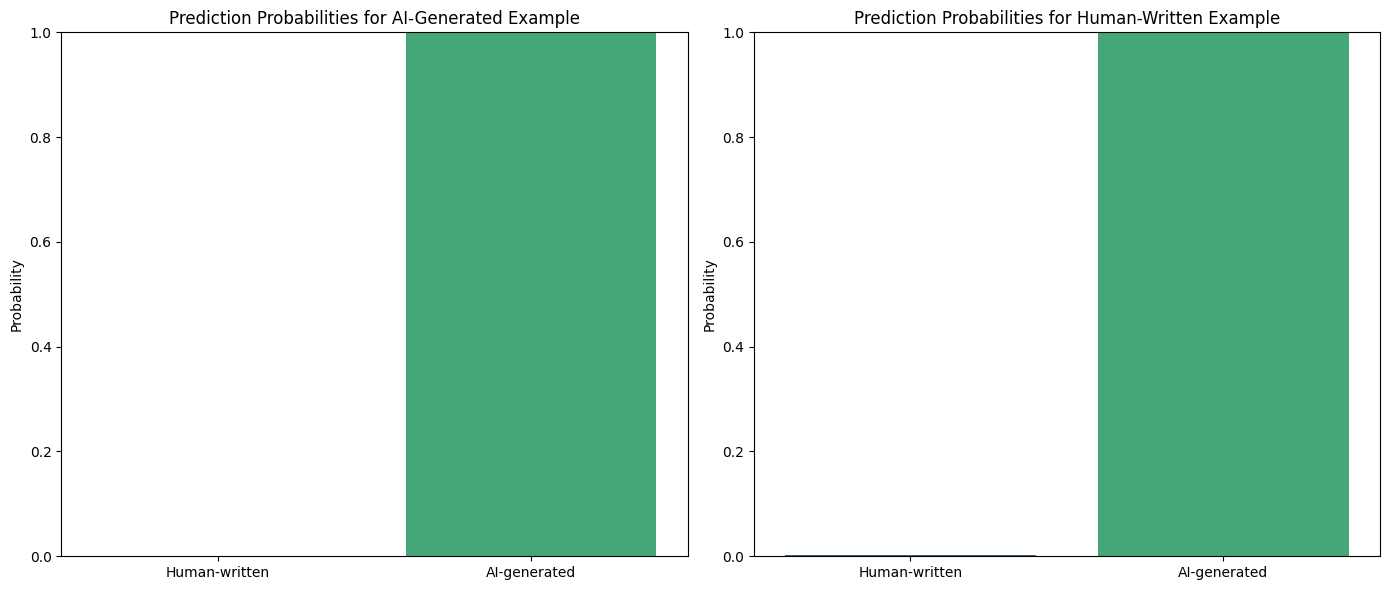

In [ ]:
def get_prediction_probabilities(text, model, tokenizer, device):
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)

    # Move inputs to the correct device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    probabilities = F.softmax(logits, dim=1)
    return probabilities.cpu().numpy().flatten()

# Get probabilities for both example essays
probs_ai_example = get_prediction_probabilities(example_essay_ai, loaded_model, loaded_tokenizer, device)
probs_human_example = get_prediction_probabilities(example_essay_human, loaded_model, loaded_tokenizer, device)

labels = ['Human-written', 'AI-generated'] # Assuming 0: Human-written, 1: AI-generated

# Create subplots for visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for AI-generated example
sns.barplot(x=labels, y=probs_ai_example, ax=axes[0], palette='viridis')
axes[0].set_title('Prediction Probabilities for AI-Generated Example')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1) # Ensure y-axis is from 0 to 1

# Plot for Human-written example
sns.barplot(x=labels, y=probs_human_example, ax=axes[1], palette='viridis')
axes[1].set_title('Prediction Probabilities for Human-Written Example')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1) # Ensure y-axis is from 0 to 1

plt.tight_layout()
plt.show()

#### 11. Analyze Prediction Probabilities on the Original Dataset

In [ ]:
def get_all_prediction_probabilities(df, model, tokenizer, device, target_label_idx=1): # target_label_idx=1 for 'AI-generated'
    all_probabilities = []
    for text in df['text']:
        probs = get_prediction_probabilities(text, model, tokenizer, device)
        all_probabilities.append(probs[target_label_idx]) # Get probability for AI-generated
    return np.array(all_probabilities)

# Get human-written and AI-generated dataframes
human_df = df[df['generated'] == 0]
ai_df = df[df['generated'] == 1]

# Get AI-generated probability for all human-written essays
human_probs_ai_label = get_all_prediction_probabilities(human_df, loaded_model, loaded_tokenizer, device)

# Get AI-generated probability for all AI-generated essays
ai_probs_ai_label = get_all_prediction_probabilities(ai_df, loaded_model, loaded_tokenizer, device)

print(f"Calculated probabilities for {len(human_probs_ai_label)} human essays and {len(ai_probs_ai_label)} AI essays.")

Calculated probabilities for 17508 human essays and 11637 AI essays.


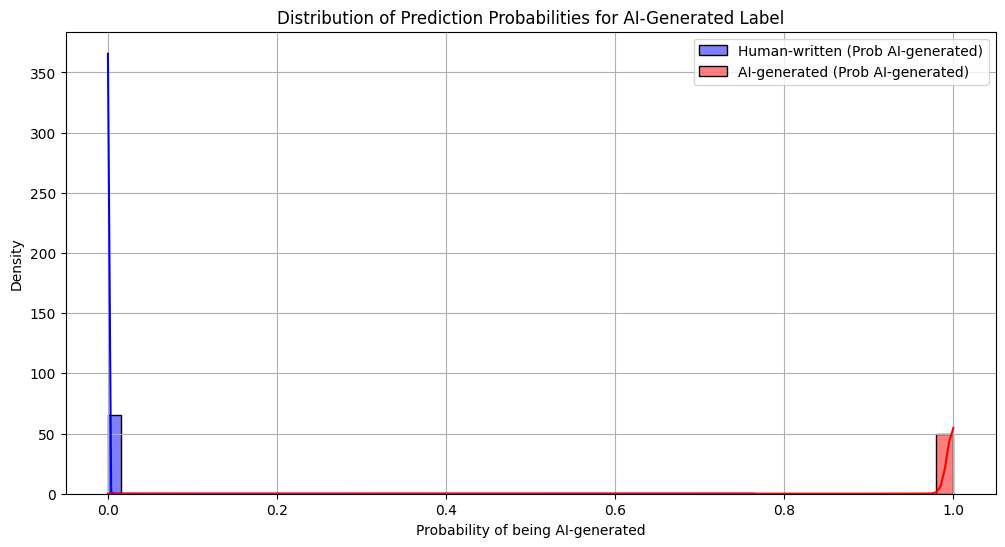

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(human_probs_ai_label, color='blue', label='Human-written (Prob AI-generated)', kde=True, stat='density', alpha=0.5, bins=50)
sns.histplot(ai_probs_ai_label, color='red', label='AI-generated (Prob AI-generated)', kde=True, stat='density', alpha=0.5, bins=50)
plt.title('Distribution of Prediction Probabilities for AI-Generated Label')
plt.xlabel('Probability of being AI-generated')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
human_essays = df[df['generated'] == 0]
sampled_human_essays = human_essays.sample(n=5, random_state=42)

print("\n--- Model Predictions on Sampled Human-written Essays ---")
for index, row in sampled_human_essays.iterrows():
    essay_text = row['text']
    prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device)
    print(f"\nOriginal Essay (first 200 chars): {essay_text[:200]}...")
    print(f"Model Prediction: {prediction}")
    print("--------------------------------------------------")


--- Model Predictions on Sampled Human-written Essays ---

Original Essay (first 200 chars): Making the right choice is easier said than done, but what an unfortunate amount of people don't realize, is that all the help they need to make a better choice, is a simple solution. They just need t...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): During my life i have watched many presidential elections on my television. To me the Electoral College on paper should work, Should being the key word. As I read the paragraphs on both why the Electo...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): In 1976 pictures where taken of Mars with the Viking 1 spacecraft from NASA. We have dicovered that the pictures look like a face on Mars. We can garentee that "aliens" did not do this. From the data ...
Model Prediction: Human-written
--------------------------

#### 12. Load and Classify a New Dataset

### Load the New Dataset for Comparison

Please specify the path to your new dataset (e.g., a `.csv` file). If it's in Google Drive, ensure your drive is mounted.

In [ ]:
# Define the path to your new dataset
# You might need to upload it to Colab or specify a Google Drive path
# Example: new_dataset_path = '/content/new_essays.csv'
# Example: new_dataset_path = '/content/drive/MyDrive/my_new_data.csv'
new_dataset_path = '/content/drive/MyDrive/PLEASE_UPDATE_WITH_YOUR_NEW_DATASET.csv' # <--- IMPORTANT: Update this path!

try:
    new_df = pd.read_csv(new_dataset_path)
    print(f"Successfully loaded new dataset from: {new_dataset_path}")
    display(new_df.head())
    print(f"New dataset shape: {new_df.shape}")
except FileNotFoundError:
    print(f"Error: New dataset not found at {new_dataset_path}. Please check the path.")
    new_df = None
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    new_df = None

Error: New dataset not found at /content/drive/MyDrive/PLEASE_UPDATE_WITH_YOUR_NEW_DATASET.csv. Please check the path.


### Classify Essays in the New Dataset

Now, let's classify each essay in the new dataset using our `loaded_model`.

In [ ]:
if new_df is not None:
    # Assuming the new dataset has a 'text' column for the essays
    # The column was renamed in cell 618fb7eb, so we can directly check for 'text'
    if 'text' in new_df.columns:
        print("Classifying essays in the new dataset with custom threshold...")
        predictions = []
        # Define a custom threshold here, e.g., 0.9 for higher confidence needed for AI
        # To classify essays with probabilities like 0.999968 and 0.999963 as 'Human-written',
        # the threshold must be higher than these values.
        custom_ai_threshold = 0.999779 # Reverted based on previous user request
        for index, row in new_df.iterrows():
            essay_text = str(row['text']) # Ensure text is string type
            # Pass the custom_ai_threshold to the prediction function
            prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device, ai_threshold=custom_ai_threshold)
            predictions.append(prediction)

        # Store predictions in a new column
        new_df['predicted_type_custom_threshold'] = predictions
        print(f"Classification complete with AI threshold = {custom_ai_threshold}. Here are the first 5 predictions:")
        display(new_df[['text', 'predicted_type_custom_threshold']].head())

        # Display the distribution of predicted types with the new threshold
        print(f"\nDistribution of Predicted Types in the New Dataset (AI threshold = {custom_ai_threshold}):")
        display(new_df['predicted_type_custom_threshold'].value_counts())

        # Also display the probabilities for better understanding
        essay_probs = []
        for index, row in new_df.iterrows():
            text = str(row['text'])
            probs = get_prediction_probabilities(text, loaded_model, loaded_tokenizer, device)
            essay_probs.append({'Human-written_Prob': probs[0], 'AI-generated_Prob': probs[1]})

        probs_df = pd.DataFrame(essay_probs)
        new_df_with_probs_custom_threshold = pd.concat([new_df, probs_df], axis=1)
        print("\nPrediction Probabilities for each essay with custom threshold:")
        display(new_df_with_probs_custom_threshold[['1', 'text', 'Human-written_Prob', 'AI-generated_Prob', 'predicted_type_custom_threshold']])


    else:
        print("Error: The new dataset does not contain a 'text' column. Please adjust the column name or preprocess your data.")
else:
    print("Cannot proceed with classification as the new dataset was not loaded.")

Cannot proceed with classification as the new dataset was not loaded.


In [ ]:
human_essays = df[df['generated'] == 0]
sampled_human_essays = human_essays.sample(n=5, random_state=42)

print("\n--- Model Predictions on Sampled Human-written Essays ---")
for index, row in sampled_human_essays.iterrows():
    essay_text = row['text']
    prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device)
    print(f"\nOriginal Essay (first 200 chars): {essay_text[:200]}...")
    print(f"Model Prediction: {prediction}")
    print("--------------------------------------------------")


--- Model Predictions on Sampled Human-written Essays ---

Original Essay (first 200 chars): Making the right choice is easier said than done, but what an unfortunate amount of people don't realize, is that all the help they need to make a better choice, is a simple solution. They just need t...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): During my life i have watched many presidential elections on my television. To me the Electoral College on paper should work, Should being the key word. As I read the paragraphs on both why the Electo...
Model Prediction: Human-written
--------------------------------------------------

Original Essay (first 200 chars): In 1976 pictures where taken of Mars with the Viking 1 spacecraft from NASA. We have dicovered that the pictures look like a face on Mars. We can garentee that "aliens" did not do this. From the data ...
Model Prediction: Human-written
--------------------------

### Load the New Dataset for Comparison

Please specify the path to your new dataset (e.g., a `.csv` file). If it's in Google Drive, ensure your drive is mounted.

In [ ]:
# Define the path to your new dataset
# You might need to upload it to Colab or specify a Google Drive path
# Example: new_dataset_path = '/content/new_essays.csv'
new_dataset_path = '/content/drive/MyDrive/Deep Learning Manual Learning Set.csv' # <--- IMPORTANT: Update this path to your new dataset!

try:
    new_df = pd.read_csv(new_dataset_path)
    print(f"Successfully loaded new dataset from: {new_dataset_path}")
    display(new_df.head())
    print(f"New dataset shape: {new_df.shape}")
except FileNotFoundError:
    print(f"Error: New dataset not found at {new_dataset_path}. Please check the path.")
    new_df = None
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    new_df = None

Error: New dataset not found at /content/drive/MyDrive/Deep Learning Manual Learning Set.csv. Please check the path.


In [ ]:
# Install openpyxl for reading .xlsx files
!pip install openpyxl

In [ ]:
# Define the path to your new dataset
# You might need to upload it to Colab or specify a Google Drive path
new_dataset_path = '/content/drive/MyDrive/Deep Learning Manual Learning Set.xlsx' # <--- IMPORTANT: Ensure correct file extension!

try:
    new_df = pd.read_excel(new_dataset_path) # Changed to read_excel
    print(f"Successfully loaded new dataset from: {new_dataset_path}")
    display(new_df.head())
    print(f"New dataset shape: {new_df.shape}")
except FileNotFoundError:
    print(f"Error: New dataset not found at {new_dataset_path}. Please check the path and file extension.")
    new_df = None
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    new_df = None

Successfully loaded new dataset from: /content/drive/MyDrive/Deep Learning Manual Learning Set.xlsx


1  \
0  2   
1  3   
2  4   
3  5   
4  6   

  In Daniel Quinn's "Ishmael," the Narrator seeks tutorage under the knowledge of a Gorilla named Ishmael. Throughout the story Ishmael generalizes humanity into two categories; The Leavers and the Takers.   Ishmael describes the Leavers as being pre-agricultural human beings who are perfectly content with their roles in life, and do not seek any change or conflict within their life. In contrast to this, the Takers are people who take place during the agricultural revolution and believe that it's Humanity's destiny to inherit and master the Earth. What sets apart the Takers from the Leavers is that the Leavers are completely at the mercy of the World and by no means wanted to control it "they had no need to exercise the gods prerogative of deciding who shall live and who shall die." (Quinn, 181) On the other hand, the Takers wanted to utilize everything the could from the world, they stopped seeing other species of life as equals, and started to believe that their role was superior to the life of others, in which case they wanted to expand their horizons. \nThe lifestyle of the Leavers and Takers has been mirrored throughout the ages of Europe, from time to time again you see the conflict between two opposing ideas.  Taker society believes that their specific way of life is the right way, and thus also tries to rule the world in some form or another. Religion, Absolutism, Imperialism, Nationalism, etc. These are all examples of what a Taker society is. A person, or a group of people trying to enforce their right as sole ruler of the World over everyone else. An example of this would be with the Napoleonic empire and the Third Reich. Attempting to conquer all that is around in order to dictate and control the world and it's people. This thus promotes only one type of ideology and mindset. That whichever way the conqueror's are living, is right. The Narrator himself, created a scenario in which the Third Reich had succeeded, in which no one would of known that their way of thinking would be considered wrong or evil. In short, the Taker society dictates that history is only written by the winners. And since, the winners did not lose or falter, then there would be no reason into questioning why their way of thinking would be wrong. The Taker Society also attempts to expand it's horizons and borders to it's limits. This can be taken in an account of smaller nation-states forming into one Nation. An example of this would be with Germany and the Second Reich or Imperialism. Nations, expanding their land, market, and resources to other parts of the world, or even unifying into a specific nation or country. Industrialism is also a way of "Expansion" and "World Domination." People doing what they can to dominate a specific market or industry in order to achieve massive success. Yet, regardless of how the Taker Society decides to go about it, one thing remains the same. Even if they decide to conquer through military means, or financial means, there is always an amount of destruction that they leave behind them. It seems that the Taker society, regardless of how they go about Taker culture, have no regard or realization of what they did or their means of achieving their success. They can expand their markets, yet pollute the environment and set unfair wages and conditions to the working force in order to achieve it. Or they can go through military conquest and cause a massive amount of casualties and destruction of homes. Regardless of how the Takers go about their means of Domination, the result will always have some drawbacks. \nIn my opinion, Europeans are one of the primary epitome's of Taker society.  Their entire history revolves around Taker beliefs and the modern world today is affected by European Imperialism. And even in the modern world; Europe still holds true by it by trying make it more, unified. An example would be something such as the European Union.  It's many nation's way o

New dataset shape: (9, 2)


In [ ]:
import os

if os.path.exists(new_dataset_path):
    print(f"File exists at: {new_dataset_path}")
else:
    print(f"File does NOT exist at: {new_dataset_path}")

File exists at: /content/drive/MyDrive/Deep Learning Manual Learning Set.xlsx


### Classify Essays in the New Dataset

Now, let's classify each essay in the new dataset using our `loaded_model`.

In [ ]:
if new_df is not None:
    # Rename the column containing essay text to 'text'
    # Based on the output, the essay text is in the second column (index 1).
    # We'll assume the second column contains the essay content.
    # Get the actual name of the second column
    essay_column_name = new_df.columns[1]
    new_df.rename(columns={essay_column_name: 'text'}, inplace=True)

    if 'text' in new_df.columns:
        print("Classifying essays in the new dataset...")
        predictions = []
        for index, row in new_df.iterrows():
            essay_text = row['text']
            prediction = predict_essay_type(essay_text, loaded_model, loaded_tokenizer, device)
            predictions.append(prediction)

        new_df['predicted_type'] = predictions
        print("Classification complete. Here are the first 5 predictions:")
        display(new_df[['text', 'predicted_type']].head())

        # Display the distribution of predicted types
        print("\nDistribution of Predicted Types in the New Dataset:")
        display(new_df['predicted_type'].value_counts())
    else:
        print("Error: The new dataset does not contain a 'text' column after renaming. Please check the structure of your Excel file.")
else:
    print("Cannot proceed with classification as the new dataset was not loaded.")

Classifying essays in the new dataset...
Classification complete. Here are the first 5 predictions:


,text,predicted_type
0,Ishmael by Daniel Quinn is a very different ki...,AI-generated
1,Geoffrey Chaucer s The Wife of Bath s Tale off...,AI-generated
2,The tension between Men and Women had been gro...,AI-generated
3,The human brain actually processes information...,Human-written
4,"Look, we’ve all been there. You’re standing in...",AI-generated



Distribution of Predicted Types in the New Dataset:


,count
predicted_type,
AI-generated,5
Human-written,4


### Analyze Prediction Probabilities for the New Dataset

Let's get the full prediction probabilities for each essay in the `new_df` to understand the model's confidence for both 'Human-written' and 'AI-generated' classes. This will help us identify if a threshold adjustment is needed.

In [ ]:
if new_df is not None and 'text' in new_df.columns:
    essay_probs = []
    for index, row in new_df.iterrows():
        text = row['text']
        probs = get_prediction_probabilities(text, loaded_model, loaded_tokenizer, device)
        essay_probs.append({'Human-written_Prob': probs[0], 'AI-generated_Prob': probs[1]})

    probs_df = pd.DataFrame(essay_probs)
    # Concatenate original df with probabilities for easier viewing
    new_df_with_probs = pd.concat([new_df, probs_df], axis=1)

    print("Prediction Probabilities for each essay in the new dataset:")
    display(new_df_with_probs[['text', 'Human-written_Prob', 'AI-generated_Prob', 'predicted_type']])

else:
    print("Cannot analyze probabilities as the new dataset is not loaded or 'text' column is missing.")

Prediction Probabilities for each essay in the new dataset:


,text,Human-written_Prob,AI-generated_Prob,predicted_type
0,Ishmael by Daniel Quinn is a very different ki...,0.000036,0.999964,AI-generated
1,Geoffrey Chaucer s The Wife of Bath s Tale off...,0.149134,0.850866,AI-generated
2,The tension between Men and Women had been gro...,0.000019,0.999981,AI-generated
3,The human brain actually processes information...,0.999503,0.000497,Human-written
4,"Look, we’ve all been there. You’re standing in...",0.000023,0.999977,AI-generated
5,"In ""Oliver Twist,"" Charles Dickens mirrors and...",0.997667,0.002333,Human-written
6,Companies are increasingly turning to artifici...,0.000015,0.999985,AI-generated
7,Kael had been staring at the candle for twenty...,0.999860,0.000140,Human-written
8,Alex Weiss in 'Should Gamers Be Prosecuted for...,0.988966,0.011034,Human-written


In [ ]:
display(new_df[['text', 'predicted_type']])

,text,predicted_type
0,Ishmael by Daniel Quinn is a very different ki...,AI-generated
1,Geoffrey Chaucer s The Wife of Bath s Tale off...,AI-generated
2,The tension between Men and Women had been gro...,AI-generated
3,The human brain actually processes information...,Human-written
4,"Look, we’ve all been there. You’re standing in...",AI-generated
5,"In ""Oliver Twist,"" Charles Dickens mirrors and...",Human-written
6,Companies are increasingly turning to artifici...,AI-generated
7,Kael had been staring at the candle for twenty...,Human-written
8,Alex Weiss in 'Should Gamers Be Prosecuted for...,Human-written


### Analyze Model Confidence for a Specific Essay

Prediction probabilities for the provided essay:
  Human-written: 0.0000
  AI-generated:  1.0000
The model predicts this essay is (with AI threshold 0.99997): AI-generated


/tmp/ipykernel_532/1267880505.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=probs, palette='viridis')


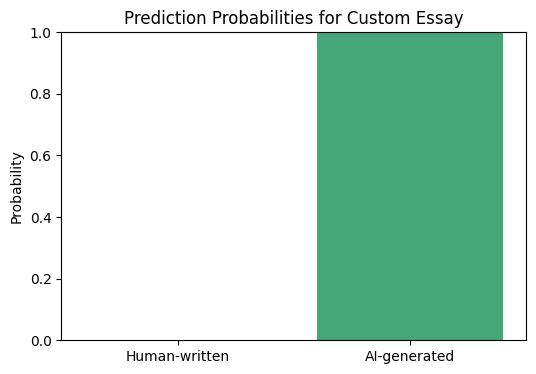

In [ ]:
essay_to_analyze = """
# PASTE YOUR ESSAY HERE

# Example of an essay:
# "Car-free cities are a crucial step towards sustainable urban living. By eliminating private vehicles from city centers, we can reduce air pollution, decrease noise levels, and create safer, more pedestrian-friendly environments. This fosters community interaction, promotes active transportation like cycling and walking, and ultimately enhances the quality of life for residents. While implementation presents challenges, the long-term benefits for public health and environmental sustainability are undeniable."
"""

# Define a custom threshold for the single essay analysis as well
custom_ai_threshold_single_essay = 0.99997 # Adjusted to a very high threshold based on user feedback

if essay_to_analyze.strip(): # Check if the essay is not empty
    probs = get_prediction_probabilities(essay_to_analyze, loaded_model, loaded_tokenizer, device)

    print(f"Prediction probabilities for the provided essay:")
    print(f"  Human-written: {probs[0]:.4f}")
    print(f"  AI-generated:  {probs[1]:.4f}")

    # Use the thresholded prediction function
    prediction_label = predict_essay_type(essay_to_analyze, loaded_model, loaded_tokenizer, device, ai_threshold=custom_ai_threshold_single_essay)
    print(f"The model predicts this essay is (with AI threshold {custom_ai_threshold_single_essay}): {prediction_label}")

    # Visualize the probabilities
    labels = ['Human-written', 'AI-generated']
    plt.figure(figsize=(6, 4))
    sns.barplot(x=labels, y=probs, palette='viridis')
    plt.title('Prediction Probabilities for Custom Essay')
    plt.ylabel('Probability')
    plt.ylim(0, 1)
    plt.show()
else:
    print("Please paste an essay into the 'essay_to_analyze' variable to get predictions.")


In [ ]:
display(new_df_with_probs)

,1,text,predicted_type,Human-written_Prob,AI-generated_Prob
0,2,Ishmael by Daniel Quinn is a very different ki...,AI-generated,0.000036,0.999964
1,3,Geoffrey Chaucer s The Wife of Bath s Tale off...,AI-generated,0.149134,0.850866
2,4,The tension between Men and Women had been gro...,AI-generated,0.000019,0.999981
3,5,The human brain actually processes information...,Human-written,0.999503,0.000497
4,6,"Look, we’ve all been there. You’re standing in...",AI-generated,0.000023,0.999977
5,7,"In ""Oliver Twist,"" Charles Dickens mirrors and...",Human-written,0.997667,0.002333
6,8,Companies are increasingly turning to artifici...,AI-generated,0.000015,0.999985
7,9,Kael had been staring at the candle for twenty...,Human-written,0.999860,0.000140
8,10,Alex Weiss in 'Should Gamers Be Prosecuted for...,Human-written,0.988966,0.011034


In [ ]:
display(new_df[['text', 'predicted_type']].head())
display(new_df['predicted_type'].value_counts())

,text,predicted_type
0,Ishmael by Daniel Quinn is a very different ki...,AI-generated
1,Geoffrey Chaucer s The Wife of Bath s Tale off...,AI-generated
2,The tension between Men and Women had been gro...,AI-generated
3,The human brain actually processes information...,Human-written
4,"Look, we’ve all been there. You’re standing in...",AI-generated


,count
predicted_type,
AI-generated,5
Human-written,4


In [ ]:
print(new_df.columns)

Index([1, 'text', 'predicted_type'], dtype='object')


In [ ]:
display(new_df.head())

,1,text,predicted_type
0,2,Ishmael by Daniel Quinn is a very different ki...,AI-generated
1,3,Geoffrey Chaucer s The Wife of Bath s Tale off...,AI-generated
2,4,The tension between Men and Women had been gro...,AI-generated
3,5,The human brain actually processes information...,Human-written
4,6,"Look, we’ve all been there. You’re standing in...",AI-generated


In [ ]:
print("Class distribution of the dataset:")
display(df['generated'].value_counts())

Class distribution of the dataset:


,count
generated,
0,17508
1,11637


The plot above shows the count of essays for each class (human-written and AI-generated). This visualization helps confirm the class balance in the dataset before training the model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_all_prediction_probabilities(df, model, tokenizer, device, target_label_idx=1): # target_label_idx=1 for 'AI-generated'
    all_probabilities = []
    for text in df['text']:
        probs = get_prediction_probabilities(text, model, tokenizer, device)
        all_probabilities.append(probs[target_label_idx]) # Get probability for AI-generated
    return np.array(all_probabilities)

# Get human-written and AI-generated dataframes
human_df = df[df['generated'] == 0]
ai_df = df[df['generated'] == 1]

# Get AI-generated probability for all human-written essays
human_probs_ai_label = get_all_prediction_probabilities(human_df, loaded_model, loaded_tokenizer, device)

# Get AI-generated probability for all AI-generated essays
ai_probs_ai_label = get_all_prediction_probabilities(ai_df, loaded_model, loaded_tokenizer, device)

print(f"Calculated probabilities for {len(human_probs_ai_label)} human essays and {len(ai_probs_ai_label)} AI essays.")

Calculated probabilities for 17508 human essays and 11637 AI essays.


In [ ]:
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# Define the path where the model and tokenizer were saved
save_directory = '/content/drive/MyDrive/distilbert_essay_detector'

# Load the tokenizer
loaded_tokenizer = DistilBertTokenizer.from_pretrained(save_directory)

# Load the model
loaded_model = DistilBertForSequenceClassification.from_pretrained(save_directory)
loaded_model.eval() # Set the model to evaluation mode

# Set device to GPU if available, else CPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
loaded_model.to(device)

print(f"Model and tokenizer loaded successfully from {save_directory} to device: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model and tokenizer loaded successfully from /content/drive/MyDrive/distilbert_essay_detector to device: cuda


In [ ]:
print(loaded_model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
print(loaded_model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
print("Top-level layers of the loaded model:")
for name, module in loaded_model.named_children():
    print(f"  - {name}: {module.__class__.__name__}")